Install Packages

In [1]:
%pip install ultralytics opencv-python scikit-image scipy networkx matplotlib pillow

  Using cached scikit_image-0.26.0-cp311-cp311-win_amd64.whl.metadata (15 kB)
  Using cached imageio-2.37.4-py3-none-any.whl.metadata (9.6 kB)
  Using cached tifffile-2026.3.3-py3-none-any.whl.metadata (31 kB)
  Using cached lazy_loader-0.5-py3-none-any.whl.metadata (5.9 kB)
   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.9 MB 2.1 MB/s eta 0:00:06
   ---- ----------------------------------- 1.3/11.9 MB 2.9 MB/s eta 0:00:04
   ------- -------------------------------- 2.1/11.9 MB 3.3 MB/s eta 0:00:03
   ---------- ----------------------------- 3.1/11.9 MB 3.6 MB/s eta 0:00:03
   ------------ --------------------------- 3.7/11.9 MB 3.7 MB/s eta 0:00:03
   --------------- ------------------------ 4.7/11.9 MB 3.8 MB/s eta 0:00:02
   ------------------- -------------------- 5.8/11.9

Imports and paths

In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch

from PIL import Image
from ultralytics import YOLO

MODEL_PATH = Path("best.pt")
IMAGE_PATH = Path("L45_003.jpg")
OUTPUT_DIR = Path("outputs")

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

DEVICE = "cpu"

print("PyTorch:", torch.__version__)
print("Device:", DEVICE)
print("Model exists:", MODEL_PATH.is_file())
print("Image exists:", IMAGE_PATH.is_file())
print("Working directory:", Path.cwd())

if not MODEL_PATH.is_file():
    raise FileNotFoundError(
        f"Model not found: {MODEL_PATH.resolve()}"
    )

if not IMAGE_PATH.is_file():
    raise FileNotFoundError(
        f"Image not found: {IMAGE_PATH.resolve()}"
    )

PyTorch: 2.12.0+cpu
Device: cpu
Model exists: True
Image exists: True
Working directory: c:\Users\User\OneDrive\Documents\ChatGPT\computer vision\pi-cent_conv


Load best.pt on CPU

In [2]:
model = YOLO(
    str(MODEL_PATH)
)

model.to(DEVICE)

class_names = {
    int(class_id): class_name
    for class_id, class_name
    in model.names.items()
}

print("Model task:", model.task)
print("Classes:", class_names)

if model.task != "segment":
    raise RuntimeError(
        "best.pt is not a segmentation model."
    )

required_classes = {
    "picc",
    "mark",
}

if set(class_names.values()) != required_classes:
    raise RuntimeError(
        f"Expected {required_classes}, "
        f"but found {set(class_names.values())}"
    )

Model task: segment
Classes: {0: 'mark', 1: 'picc'}


Run CPU Inference

In [16]:
predictions = model.predict(
    source=str(IMAGE_PATH),
    imgsz=960,
    conf=0.20,
    device=DEVICE,
    retina_masks=True,
    verbose=False,
)

if len(predictions) != 1:
    raise RuntimeError(
        f"Expected one prediction result, "
        f"received {len(predictions)}."
    )

result = predictions[0]

print("Original image shape:", result.orig_shape)
print(
    "Detected instances:",
    0 if result.boxes is None
    else len(result.boxes),
)

Original image shape: (3072, 3072)
Detected instances: 4


Extract Original-resolution masks

In [17]:
original_bgr = result.orig_img
original_rgb = cv2.cvtColor(
    original_bgr,
    cv2.COLOR_BGR2RGB,
)

image_height, image_width = (
    original_rgb.shape[:2]
)

instances = []

if (
    result.masks is not None
    and result.boxes is not None
):
    predicted_masks = (
        result.masks.data
        .detach()
        .cpu()
        .numpy()
    )

    predicted_classes = (
        result.boxes.cls
        .detach()
        .cpu()
        .numpy()
        .astype(int)
    )

    predicted_confidences = (
        result.boxes.conf
        .detach()
        .cpu()
        .numpy()
    )

    for index, predicted_mask in enumerate(
        predicted_masks
    ):
        if predicted_mask.shape != (
            image_height,
            image_width,
        ):
            predicted_mask = cv2.resize(
                predicted_mask,
                (
                    image_width,
                    image_height,
                ),
                interpolation=cv2.INTER_NEAREST,
            )

        binary_mask = (
            predicted_mask >= 0.5
        ).astype(np.uint8)

        class_id = int(
            predicted_classes[index]
        )

        instances.append(
            {
                "index": index,
                "class_id": class_id,
                "class_name": (
                    class_names[class_id]
                ),
                "confidence": float(
                    predicted_confidences[index]
                ),
                "mask": binary_mask,
                "area_pixels": int(
                    binary_mask.sum()
                ),
            }
        )

print("Extracted instances:", len(instances))

for instance in instances:
    print(
        f"Instance {instance['index']}:",
        instance["class_name"],
        "| confidence:",
        f"{instance['confidence']:.4f}",
        "| mask area:",
        instance["area_pixels"],
    )

Extracted instances: 4
Instance 0: picc | confidence: 0.8845 | mask area: 53848
Instance 1: mark | confidence: 0.8486 | mask area: 870
Instance 2: mark | confidence: 0.8212 | mask area: 809
Instance 3: mark | confidence: 0.7460 | mask area: 806


Count PICC and mark instances

In [12]:
picc_instances = [
    instance
    for instance in instances
    if instance["class_name"] == "picc"
]

mark_instances = [
    instance
    for instance in instances
    if instance["class_name"] == "mark"
]

print("PICC instances:", len(picc_instances))
print("Mark instances:", len(mark_instances))

if len(picc_instances) == 0:
    print(
        "REJECT: No PICC mask detected."
    )

if len(picc_instances) > 1:
    print(
        "WARNING: Multiple PICC masks detected."
    )

if len(mark_instances) < 2:
    print(
        "REJECT: Fewer than two marks detected."
    )

PICC instances: 2
Mark instances: 2


Visualize raw predictions

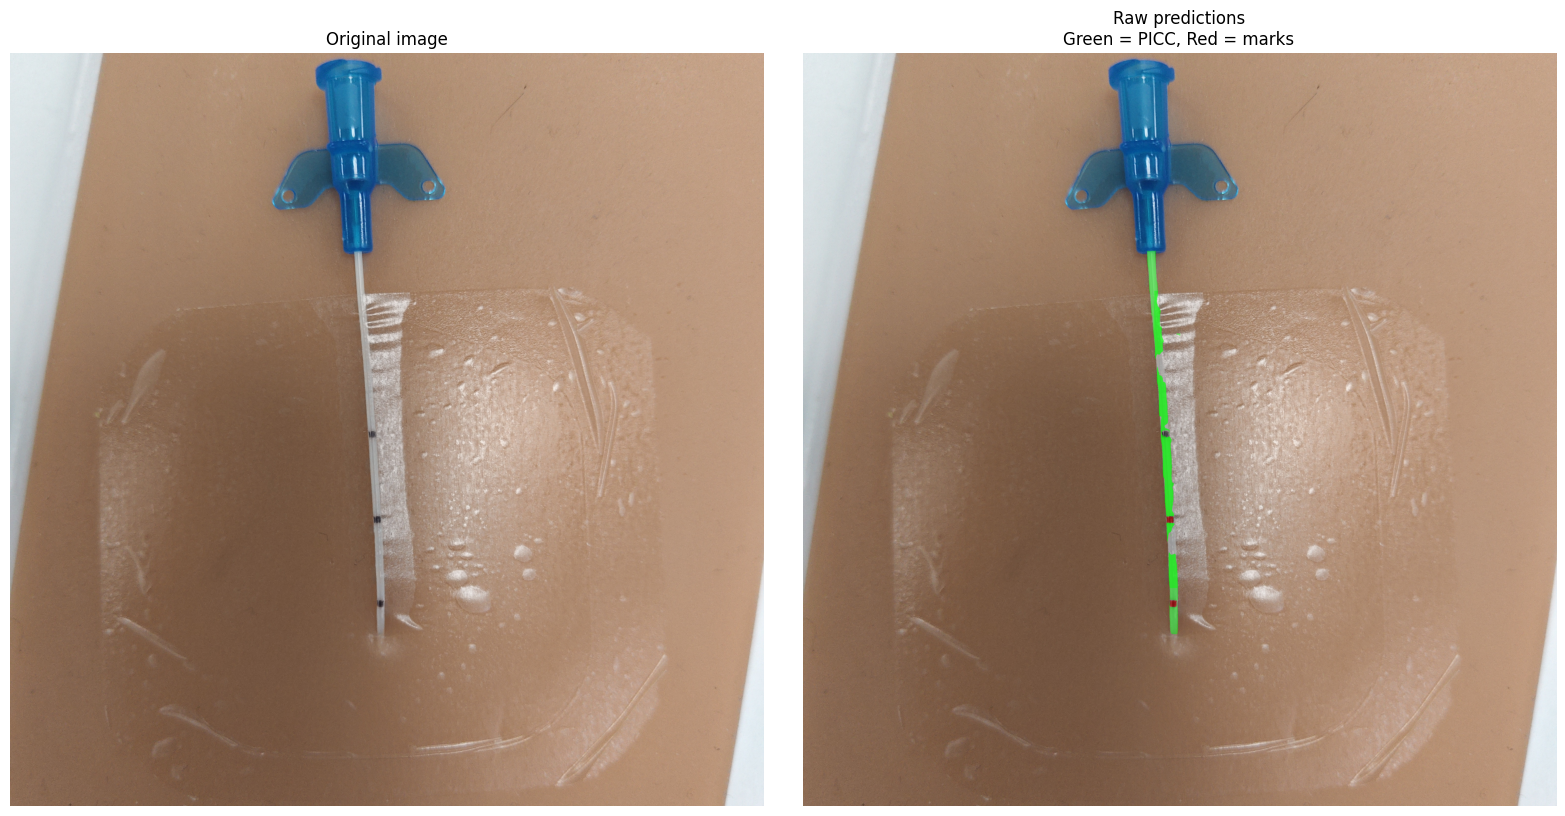

In [13]:
overlay = original_rgb.copy()

picc_colour = np.array(
    [0, 255, 0],
    dtype=np.uint8,
)

mark_colour = np.array(
    [255, 0, 0],
    dtype=np.uint8,
)

for instance in instances:
    mask = instance["mask"].astype(bool)

    if instance["class_name"] == "picc":
        colour = picc_colour
    else:
        colour = mark_colour

    overlay[mask] = (
        0.55 * overlay[mask]
        + 0.45 * colour
    ).astype(np.uint8)

figure, axes = plt.subplots(
    1,
    2,
    figsize=(16, 8),
)

axes[0].imshow(original_rgb)
axes[0].set_title("Original image")
axes[0].axis("off")

axes[1].imshow(overlay)
axes[1].set_title(
    "Raw predictions\n"
    "Green = PICC, Red = marks"
)
axes[1].axis("off")

plt.tight_layout()
plt.show()

Saved the raw prediction overlay

In [20]:
raw_output_path = (
    OUTPUT_DIR
    / f"{IMAGE_PATH.stem}_raw_predictions.png"
)

Image.fromarray(overlay).save(
    raw_output_path
)

print(
    "Saved:",
    raw_output_path.resolve(),
)

Saved: C:\Users\User\OneDrive\Documents\ChatGPT\computer vision\pi-cent_conv\outputs\L45_003_raw_predictions.png


Select the PICC mask

In [21]:
if len(picc_instances) == 0:
    raise RuntimeError(
        "No PICC instance detected."
    )

if len(picc_instances) > 1:
    raise RuntimeError(
        "Multiple PICC instances detected. "
        "Do not select one automatically yet."
    )

selected_picc = picc_instances[0]

raw_picc_mask = (
    selected_picc["mask"]
    .astype(np.uint8)
)

print(
    "PICC confidence:",
    selected_picc["confidence"],
)

print(
    "Raw PICC mask area:",
    int(raw_picc_mask.sum()),
)

PICC confidence: 0.8844937682151794
Raw PICC mask area: 53848


Keep the largest connected component

In [22]:
component_count, component_labels, statistics, _ = (
    cv2.connectedComponentsWithStats(
        raw_picc_mask,
        connectivity=8,
    )
)

foreground_components = (
    component_count - 1
)

print(
    "Foreground components:",
    foreground_components,
)

if foreground_components == 0:
    raise RuntimeError(
        "PICC mask contains no foreground."
    )

component_areas = statistics[
    1:,
    cv2.CC_STAT_AREA,
]

largest_component_label = (
    1 + int(np.argmax(component_areas))
)

cleaned_picc_mask = (
    component_labels
    == largest_component_label
).astype(np.uint8)

raw_area = int(
    raw_picc_mask.sum()
)

cleaned_area = int(
    cleaned_picc_mask.sum()
)

retained_ratio = (
    cleaned_area / raw_area
    if raw_area > 0
    else 0.0
)

print("Raw area:", raw_area)
print("Cleaned area:", cleaned_area)
print(
    "Retained-area ratio:",
    f"{retained_ratio:.4f}",
)

if retained_ratio < 0.90:
    print(
        "WARNING: More than 10% of the "
        "predicted PICC mask was discarded."
    )

Foreground components: 4
Raw area: 53848
Cleaned area: 26461
Retained-area ratio: 0.4914


Compare raw and clean masks

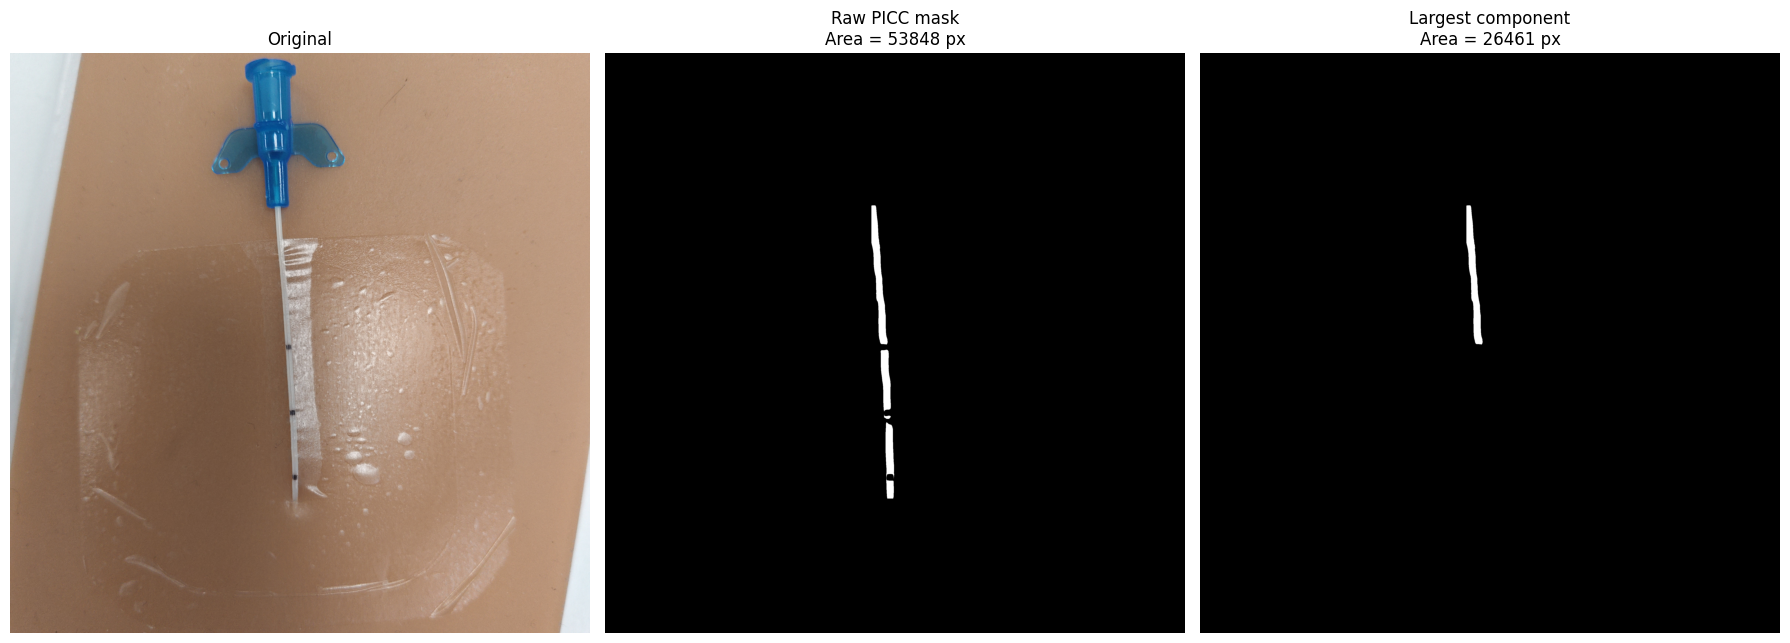

In [23]:
figure, axes = plt.subplots(
    1,
    3,
    figsize=(18, 7),
)

axes[0].imshow(original_rgb)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(
    raw_picc_mask,
    cmap="gray",
)
axes[1].set_title(
    f"Raw PICC mask\n"
    f"Area = {raw_area} px"
)
axes[1].axis("off")

axes[2].imshow(
    cleaned_picc_mask,
    cmap="gray",
)
axes[2].set_title(
    f"Largest component\n"
    f"Area = {cleaned_area} px"
)
axes[2].axis("off")

plt.tight_layout()
plt.show()

Skeletonize only the clean PICC mask

In [24]:
from skimage.morphology import skeletonize

skeleton_mask = skeletonize(
    cleaned_picc_mask.astype(bool)
)

skeleton_pixel_count = int(
    skeleton_mask.sum()
)

print(
    "Skeleton pixels:",
    skeleton_pixel_count,
)

if skeleton_pixel_count < 2:
    raise RuntimeError(
        "Skeleton is empty or too short."
    )

Skeleton pixels: 710


Convert the skeleton into a weighted graph

In [25]:
import math
import networkx as nx

skeleton_graph = nx.Graph()

skeleton_coordinates = np.argwhere(
    skeleton_mask
)

for row, column in skeleton_coordinates:
    skeleton_graph.add_node(
        (int(row), int(column))
    )

neighbour_offsets = [
    (-1, -1),
    (-1, 0),
    (-1, 1),
    (0, 1),
]

for row, column in skeleton_coordinates:
    current = (
        int(row),
        int(column),
    )

    for row_offset, column_offset in (
        neighbour_offsets
    ):
        neighbour = (
            int(row + row_offset),
            int(column + column_offset),
        )

        if neighbour not in skeleton_graph:
            continue

        weight = (
            math.sqrt(2)
            if row_offset != 0
            and column_offset != 0
            else 1.0
        )

        skeleton_graph.add_edge(
            current,
            neighbour,
            weight=weight,
        )

print(
    "Skeleton graph nodes:",
    skeleton_graph.number_of_nodes(),
)

print(
    "Skeleton graph edges:",
    skeleton_graph.number_of_edges(),
)

Skeleton graph nodes: 710
Skeleton graph edges: 709


Keep the largest skeleton component

In [26]:
connected_components = list(
    nx.connected_components(
        skeleton_graph
    )
)

print(
    "Skeleton connected components:",
    len(connected_components),
)

largest_nodes = max(
    connected_components,
    key=len,
)

main_graph = (
    skeleton_graph.subgraph(
        largest_nodes
    ).copy()
)

retained_skeleton_ratio = (
    main_graph.number_of_nodes()
    / skeleton_graph.number_of_nodes()
)

print(
    "Main skeleton nodes:",
    main_graph.number_of_nodes(),
)

print(
    "Retained skeleton ratio:",
    f"{retained_skeleton_ratio:.4f}",
)

Skeleton connected components: 1
Main skeleton nodes: 710
Retained skeleton ratio: 1.0000


Find skeleton endpoints

In [27]:
skeleton_endpoints = [
    node
    for node, degree
    in main_graph.degree()
    if degree == 1
]

branch_points = [
    node
    for node, degree
    in main_graph.degree()
    if degree > 2
]

print(
    "Skeleton endpoints:",
    len(skeleton_endpoints),
)

print(
    "Skeleton branch points:",
    len(branch_points),
)

if len(skeleton_endpoints) < 2:
    raise RuntimeError(
        "Fewer than two skeleton endpoints."
    )

Skeleton endpoints: 2
Skeleton branch points: 0


Extract the longest endpoint-to-endpoint path

In [28]:
from itertools import combinations

longest_path_length = -1.0
longest_endpoint_pair = None

for first_endpoint, second_endpoint in (
    combinations(
        skeleton_endpoints,
        2,
    )
):
    try:
        path_length = (
            nx.shortest_path_length(
                main_graph,
                source=first_endpoint,
                target=second_endpoint,
                weight="weight",
            )
        )
    except nx.NetworkXNoPath:
        continue

    if path_length > longest_path_length:
        longest_path_length = float(
            path_length
        )

        longest_endpoint_pair = (
            first_endpoint,
            second_endpoint,
        )

if longest_endpoint_pair is None:
    raise RuntimeError(
        "No valid endpoint-to-endpoint "
        "skeleton path was found."
    )

ordered_path = nx.shortest_path(
    main_graph,
    source=longest_endpoint_pair[0],
    target=longest_endpoint_pair[1],
    weight="weight",
)

ordered_path_array = np.asarray(
    ordered_path,
    dtype=np.int32,
)

endpoint_1 = np.asarray(
    longest_endpoint_pair[0],
    dtype=np.float64,
)

endpoint_2 = np.asarray(
    longest_endpoint_pair[1],
    dtype=np.float64,
)

euclidean_endpoint_distance = float(
    np.linalg.norm(
        endpoint_2 - endpoint_1
    )
)

curvature_ratio = (
    longest_path_length
    / euclidean_endpoint_distance
    if euclidean_endpoint_distance > 0
    else float("inf")
)

print(
    "Ordered path points:",
    len(ordered_path),
)

print(
    "Centreline length:",
    f"{longest_path_length:.2f} px",
)

print(
    "Euclidean endpoint distance:",
    f"{euclidean_endpoint_distance:.2f} px",
)

print(
    "Centreline/Euclidean ratio:",
    f"{curvature_ratio:.4f}",
)

print(
    "Unordered endpoints:",
    longest_endpoint_pair,
)

Ordered path points: 710
Centreline length: 733.44 px
Euclidean endpoint distance: 711.29 px
Centreline/Euclidean ratio: 1.0311
Unordered endpoints: ((817, 1422), (1526, 1479))


Display the extracted centreline

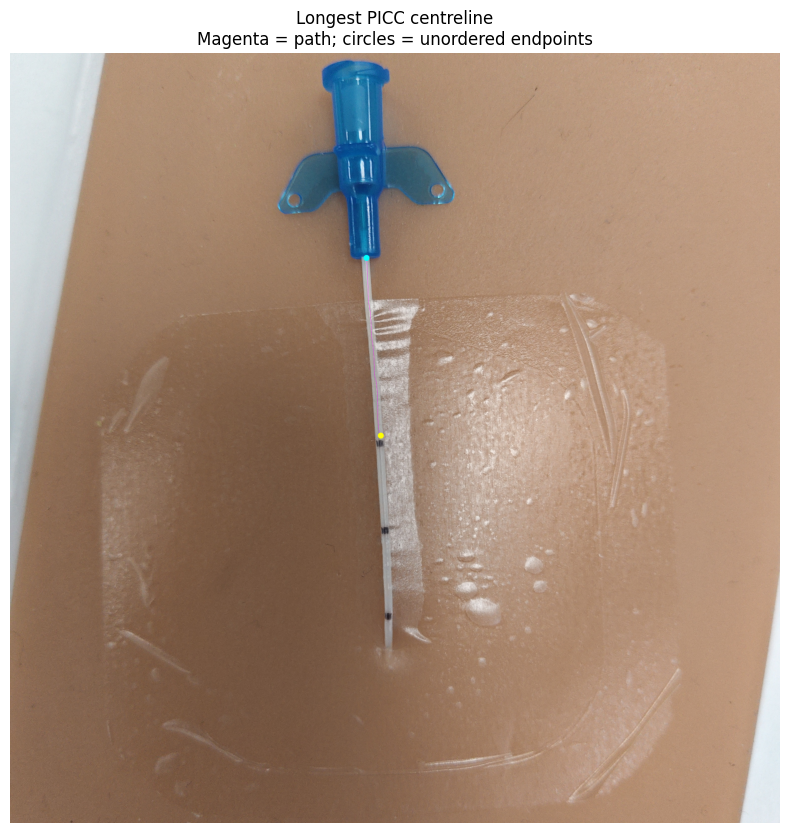

In [29]:
centreline_overlay = (
    original_rgb.copy()
)

path_rows = ordered_path_array[:, 0]
path_columns = ordered_path_array[:, 1]

centreline_overlay[
    path_rows,
    path_columns,
] = [255, 0, 255]

first_row, first_column = (
    longest_endpoint_pair[0]
)

second_row, second_column = (
    longest_endpoint_pair[1]
)

cv2.circle(
    centreline_overlay,
    (
        int(first_column),
        int(first_row),
    ),
    radius=12,
    color=(0, 255, 255),
    thickness=-1,
)

cv2.circle(
    centreline_overlay,
    (
        int(second_column),
        int(second_row),
    ),
    radius=12,
    color=(255, 255, 0),
    thickness=-1,
)

plt.figure(figsize=(10, 10))
plt.imshow(centreline_overlay)
plt.title(
    "Longest PICC centreline\n"
    "Magenta = path; circles = unordered endpoints"
)
plt.axis("off")
plt.show()

In [30]:
inference_sizes = [
    960,
    1280,
    1536,
]

for inference_size in inference_sizes:
    comparison = model.predict(
        source=str(IMAGE_PATH),
        imgsz=inference_size,
        conf=0.20,
        device="cpu",
        retina_masks=True,
        verbose=False,
    )

    result_at_size = comparison[0]

    print(
        "Image size:",
        inference_size,
        "| detections:",
        len(result_at_size.boxes),
    )

Image size: 960 | detections: 4
Image size: 1280 | detections: 5
Image size: 1536 | detections: 4
